# Pothole Detection — Preprocessing & Model Building (YOLOv8)

This notebook continues from your dataset analysis notebook (`kaggle_dataset_analysis.ipynb`).
Your dataset is already in **YOLO format**:

```
pothole_Dataset/
├── train/
│   ├── images/
│   └── labels/
├── valid/
│   ├── images/
│   └── labels/
├── data.yaml
└── sample_video.mp4
```

Because it's already in YOLO format with `data.yaml`, the natural model choice is **Ultralytics YOLOv8**
(single-class object detection — pothole). This notebook covers:

1. Environment setup
2. Dataset verification (sanity checks)
3. Fixing/validating `data.yaml`
4. Exploratory checks relevant to preprocessing (class balance, image sizes, corrupt files)
5. YOLOv8 handles resizing/augmentation internally — we configure it explicitly
6. Model building (loading pretrained YOLOv8)
7. Training
8. Evaluation (metrics + plots)
9. Inference on validation images
10. Inference on `sample_video.mp4`
11. Exporting the trained model

> Run cells top to bottom. Adjust `dataset_path` in the next cell to match your machine.


## 1. Environment Setup

In [1]:
# Install Ultralytics (YOLOv8). Run once, then you can comment this out.
%pip install ultralytics opencv-python matplotlib pyyaml --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 4.1 MB/s eta 0:00:00


In [2]:
import os
import yaml
import random
import shutil
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO

import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Torch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "anggadwisunarto/potholes-detection-yolov8"
)

print(path)

Using Colab cache for faster access to the 'potholes-detection-yolov8' dataset.
/kaggle/input/potholes-detection-yolov8


In [6]:
from pathlib import Path

dataset_path = Path("/kaggle/input/potholes-detection-yolov8")

print(list(dataset_path.iterdir()))

[PosixPath('/kaggle/input/potholes-detection-yolov8/data.yaml'), PosixPath('/kaggle/input/potholes-detection-yolov8/valid'), PosixPath('/kaggle/input/potholes-detection-yolov8/sample_video.mp4'), PosixPath('/kaggle/input/potholes-detection-yolov8/train')]


## 2. Dataset Paths & Verification

Same checks as your EDA notebook, kept here so this notebook is self-contained.

In [7]:
print("YAML files:")
for f in dataset_path.rglob("*.yaml"):
    print(f)

print("\nFolders:")
for f in dataset_path.iterdir():
    print(f)

YAML files:
/kaggle/input/potholes-detection-yolov8/data.yaml

Folders:
/kaggle/input/potholes-detection-yolov8/data.yaml
/kaggle/input/potholes-detection-yolov8/valid
/kaggle/input/potholes-detection-yolov8/sample_video.mp4
/kaggle/input/potholes-detection-yolov8/train


In [8]:
train_images = dataset_path / "train" / "images"
train_labels = dataset_path / "train" / "labels"

valid_images = dataset_path / "valid" / "images"
valid_labels = dataset_path / "valid" / "labels"

print("TRAIN -> images:", len(list(train_images.glob("*"))),
      "| labels:", len(list(train_labels.glob("*.txt"))))

print("VALID -> images:", len(list(valid_images.glob("*"))),
      "| labels:", len(list(valid_labels.glob("*.txt"))))

TRAIN -> images: 1581 | labels: 1581
VALID -> images: 396 | labels: 396


In [9]:
# Check for images without labels / labels without images (should be 0/0 ideally)
def mismatch_report(images_dir, labels_dir, split_name):
    image_names = {f.stem for f in images_dir.glob("*")}
    label_names = {f.stem for f in labels_dir.glob("*.txt")}

    missing_labels = image_names - label_names
    orphan_labels = label_names - image_names

    print(f"{split_name}: images without labels = {len(missing_labels)}, "
          f"labels without images = {len(orphan_labels)}")
    return missing_labels, orphan_labels

train_missing, train_orphan = mismatch_report(train_images, train_labels, "TRAIN")
valid_missing, valid_orphan = mismatch_report(valid_images, valid_labels, "VALID")


TRAIN: images without labels = 0, labels without images = 0
VALID: images without labels = 0, labels without images = 0


In [10]:
train_image_files = list(train_images.glob("*"))
valid_image_files = list(valid_images.glob("*"))

In [11]:
# Check for corrupt / unreadable images (important preprocessing step before training)
def find_corrupt_images(image_paths):
    corrupt = []
    for p in image_paths:
        try:
            img = Image.open(p)
            img.verify()
        except Exception:
            corrupt.append(p)
    return corrupt

corrupt_train = find_corrupt_images(train_image_files)
corrupt_valid = find_corrupt_images(valid_image_files)

print("Corrupt train images:", len(corrupt_train))
print("Corrupt valid images:", len(corrupt_valid))

# If any are found, remove or replace them before training:
# for p in corrupt_train + corrupt_valid:
#     p.unlink()


Corrupt train images: 0
Corrupt valid images: 0


## 3. Class Balance & Image Size Distribution

Understanding these helps decide augmentation strength and `imgsz` for training.

In [12]:
# Class distribution (bounding boxes per class) in the training set
class_counter = Counter()

for label_file in train_labels.glob("*.txt"):
    with open(label_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                class_counter[int(parts[0])] += 1

print("Class distribution (train):", dict(class_counter))


Class distribution (train): {0: 5942}


Width  -> min: 135 max: 4200 avg: 729
Height -> min: 148 max: 2800 avg: 504


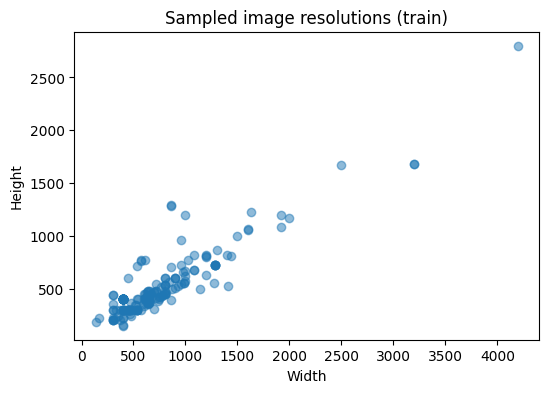

In [13]:
# Image size distribution — YOLO will resize everything to `imgsz`,
# but it's useful to know the native resolution range of your dataset.
widths, heights = [], []

sample_for_size_check = random.sample(train_image_files, min(200, len(train_image_files)))

for img_path in sample_for_size_check:
    with Image.open(img_path) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)

print("Width  -> min:", min(widths), "max:", max(widths), "avg:", sum(widths)//len(widths))
print("Height -> min:", min(heights), "max:", max(heights), "avg:", sum(heights)//len(heights))

plt.figure(figsize=(6, 4))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Sampled image resolutions (train)")
plt.show()


## 4. Preprocessing Notes

Unlike a classic ML pipeline where you manually resize/normalize images, **YOLOv8 handles this internally**
during training:

- **Resizing** → controlled by the `imgsz` parameter passed to `model.train()`.
- **Normalization** (pixel scaling to 0–1) → done automatically by Ultralytics.
- **Augmentation** (flips, mosaic, HSV jitter, scaling, etc.) → configurable via `model.train()` arguments
  (`hsv_h`, `hsv_s`, `hsv_v`, `degrees`, `translate`, `scale`, `fliplr`, `mosaic`, etc.). Defaults are sensible
  for most datasets.

So the actual "preprocessing" work for a YOLO dataset is exactly what you've already done:
1. Confirm image/label pairing (done above).
2. Confirm annotation format validity (done in your EDA notebook).
3. Remove/fix corrupt images (done above).
4. Make sure `data.yaml` correctly points to the folders and lists the classes.

We fix/verify `data.yaml` next.

In [14]:
# View current data.yaml
data_yaml_path = dataset_path / "data.yaml"
with open(data_yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

print(data_yaml)


{'train': '/kaggle/input/potholes-detection-yolov8/train/images', 'val': '/kaggle/input/potholes-detection-yolov8/valid/images', 'nc': 1, 'names': ['pothole']}


In [15]:
import shutil

shutil.copy(
    "/kaggle/input/potholes-detection-yolov8/data.yaml",
    "/content/data.yaml"
)

'/content/data.yaml'

In [16]:
with open("/content/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

data_yaml["train"] = str(train_images)
data_yaml["val"] = str(valid_images)
data_yaml["nc"] = 1
data_yaml["names"] = ["pothole"]

with open("/content/data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f)

print(data_yaml)

{'train': '/kaggle/input/potholes-detection-yolov8/train/images', 'val': '/kaggle/input/potholes-detection-yolov8/valid/images', 'nc': 1, 'names': ['pothole']}


In [17]:
# Update the writable copy of data.yaml

with open("/content/data.yaml", "r") as f:
    data_yaml = yaml.safe_load(f)

data_yaml["train"] = str(train_images)
data_yaml["val"] = str(valid_images)
data_yaml["nc"] = 1
data_yaml["names"] = ["pothole"]

with open("/content/data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f)

print("Updated data.yaml:")
print(yaml.safe_dump(data_yaml))

Updated data.yaml:
names:
- pothole
nc: 1
train: /kaggle/input/potholes-detection-yolov8/train/images
val: /kaggle/input/potholes-detection-yolov8/valid/images



## 5. Visual Sanity Check

Plot a few train/valid images with their bounding boxes drawn — quick confirmation everything lines up.

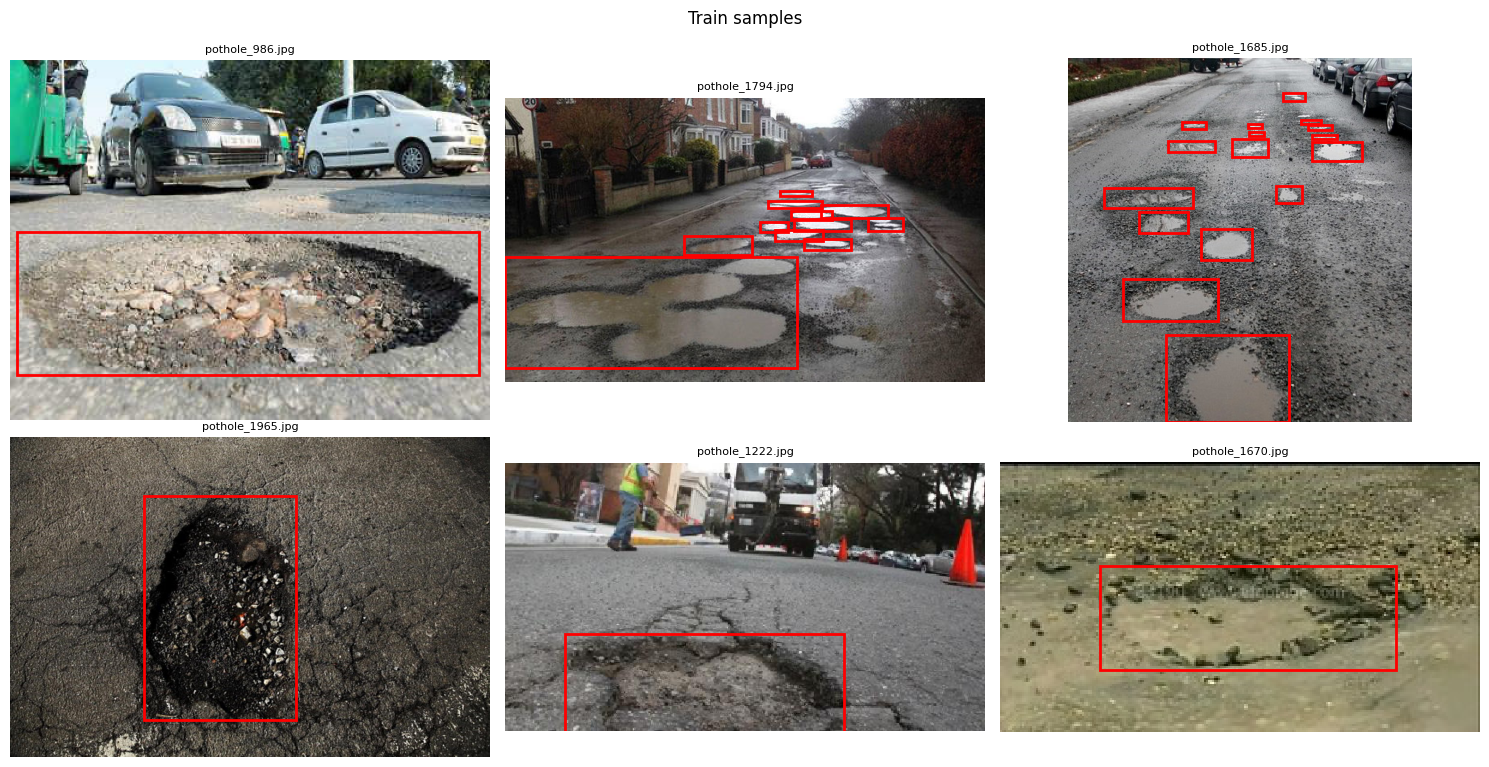

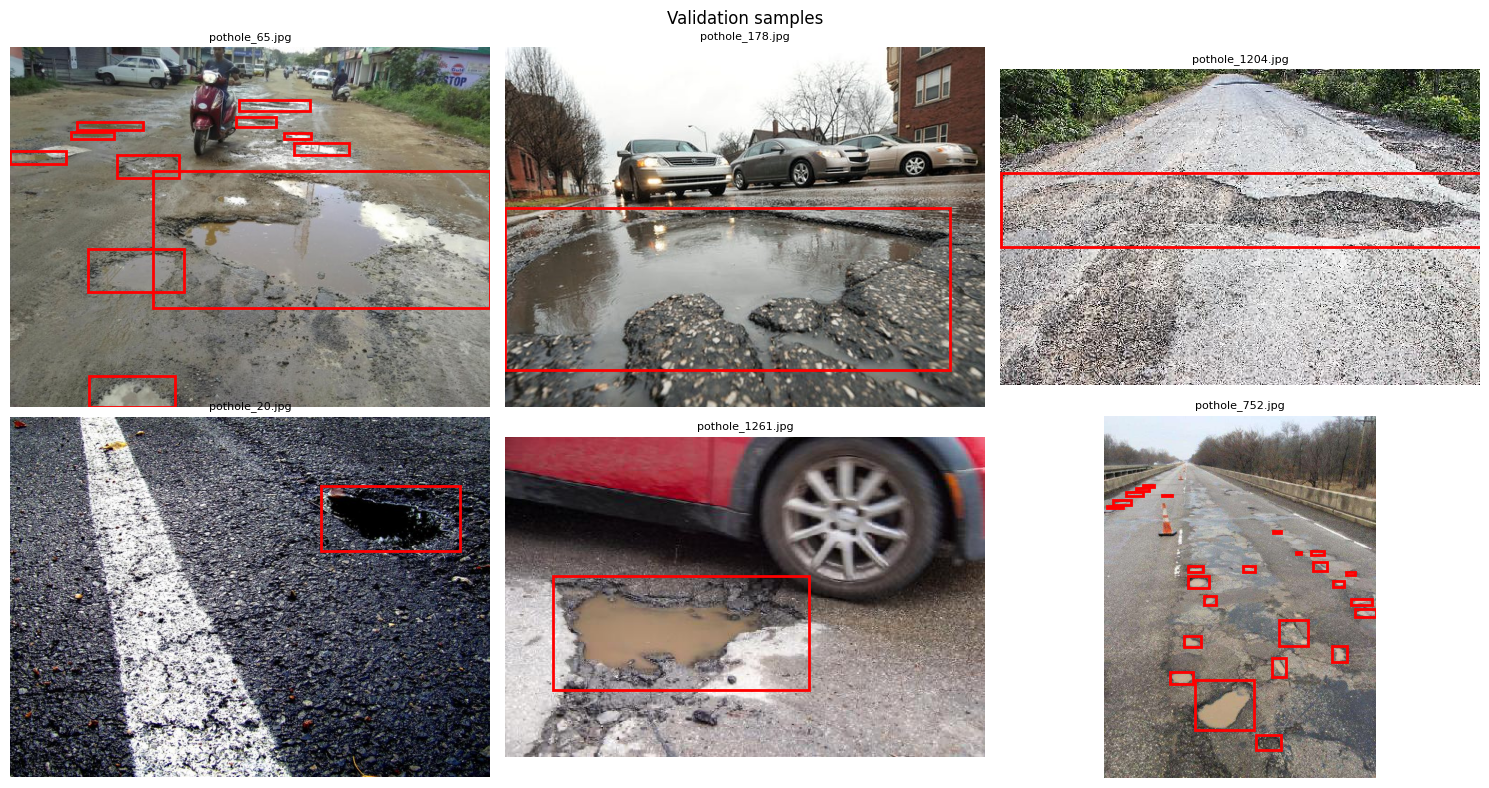

In [18]:
def show_samples(images_dir, labels_dir, n=6, title="Samples"):
    files = random.sample(list(images_dir.glob("*")), min(n, len(list(images_dir.glob("*")))))
    plt.figure(figsize=(15, 8))

    for i, image_file in enumerate(files):
        image = Image.open(image_file)
        width, height = image.size

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.axis("off")
        plt.title(image_file.name, fontsize=8)

        label_file = labels_dir / (image_file.stem + ".txt")
        if label_file.exists():
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, x, y, w, h = map(float, parts)
                        x1 = (x - w / 2) * width
                        y1 = (y - h / 2) * height
                        rect = plt.Rectangle((x1, y1), w * width, h * height,
                                              fill=False, edgecolor="red", linewidth=2)
                        plt.gca().add_patch(rect)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_images, train_labels, title="Train samples")
show_samples(valid_images, valid_labels, title="Validation samples")


## 6. Model Building

We use **YOLOv8** from Ultralytics. Choose a base checkpoint depending on your hardware:

| Model     | Size   | Speed | Accuracy | Good for |
|-----------|--------|-------|----------|----------|
| yolov8n.pt | Nano  | Fastest | Lowest | CPU / weak GPU, quick prototyping |
| yolov8s.pt | Small | Fast    | Good   | Balanced choice — recommended start |
| yolov8m.pt | Medium| Medium  | Better | Decent GPU, more training time |
| yolov8l.pt | Large | Slow    | High   | Strong GPU |
| yolov8x.pt | XL    | Slowest | Highest| Strong GPU, best accuracy |

Start with `yolov8n.pt` or `yolov8s.pt` for a single-class problem like pothole detection —
it's usually enough and trains much faster.

In [19]:
model = YOLO("yolov8s.pt")  # loads pretrained COCO weights, downloads automatically first time


In [20]:
!nvidia-smi

Thu Sep 10 14:03:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [21]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 7. Training

Adjust `epochs`, `batch`, and `imgsz` based on your GPU/CPU capacity.

In [22]:
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    project="pothole_runs",
    name="yolov8s_pothole",
    exist_ok=True,

    # Augmentation
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,

    device=0
)

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_pothole, nbs=64, nms=None, opset=None, optimize=Fa

## 8. Evaluate on Validation Set

In [23]:
metrics = model.val()

print("mAP50-95:", metrics.box.map)
print("mAP50:   ", metrics.box.map50)
print("mAP75:   ", metrics.box.map75)
print("Precision:", metrics.box.mp)
print("Recall:   ", metrics.box.mr)


Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 654.3±683.2 MB/s, size: 331.5 KB)
val: Scanning /kaggle/input/potholes-detection-yolov8/valid/labels... 394 images, 0 backgrounds, 2 corrupt: 100% ━━━━━━━━━━━━ 396/396 187.6it/s 2.1s
val: /kaggle/input/potholes-detection-yolov8/valid/images/pothole_1870.jpg: ignoring corrupt image/label: Invalid image format GIF. Supported formats are:
images: {'tiff', 'avif', 'heif', 'webp', 'png', 'jpg', 'dng', 'tif', 'heic', 'jpeg', 'jp2', 'bmp', 'mpo'}
videos: {'m4v', 'asf', 'avi', 'mpg', 'wmv', 'webm', 'mpeg', 'mkv', 'gif', 'ts', 'mp4', 'mov'}
val: /kaggle/input/potholes-detection-yolov8/valid/images/pothole_975.jpg: ignoring corrupt image/label: [Errno 30] Read-only file system: '/kaggle/input/potholes-detection-yolov8/valid/images/pothole_975.jpg'
WARNING ⚠️ val: Cache directory /kag

In [24]:
# Ultralytics automatically saves training curves and confusion matrix — display them
run_dir = Path("pothole_runs/yolov8s_pothole")

for img_name in ["results.png", "confusion_matrix.png", "PR_curve.png", "F1_curve.png"]:
    img_path = run_dir / img_name
    if img_path.exists():
        plt.figure(figsize=(8, 6))
        plt.imshow(Image.open(img_path))
        plt.axis("off")
        plt.title(img_name)
        plt.show()


## 9. Inference on Validation Images

In [26]:
from pathlib import Path
from ultralytics import YOLO
import random
import matplotlib.pyplot as plt

run_dir = Path("/content/runs/detect/pothole_runs/yolov8s_pothole")

best_model_path = run_dir / "weights" / "best.pt"

print("Model exists:", best_model_path.exists())
print("Model path:", best_model_path)

best_model = YOLO(str(best_model_path))

Model exists: True
Model path: /content/runs/detect/pothole_runs/yolov8s_pothole/weights/best.pt



0: 640x640 1 pothole, 12.7ms
1: 640x640 1 pothole, 12.7ms
2: 640x640 3 potholes, 12.7ms
3: 640x640 1 pothole, 12.7ms
4: 640x640 3 potholes, 12.7ms
5: 640x640 1 pothole, 12.7ms
Speed: 1.5ms preprocess, 12.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


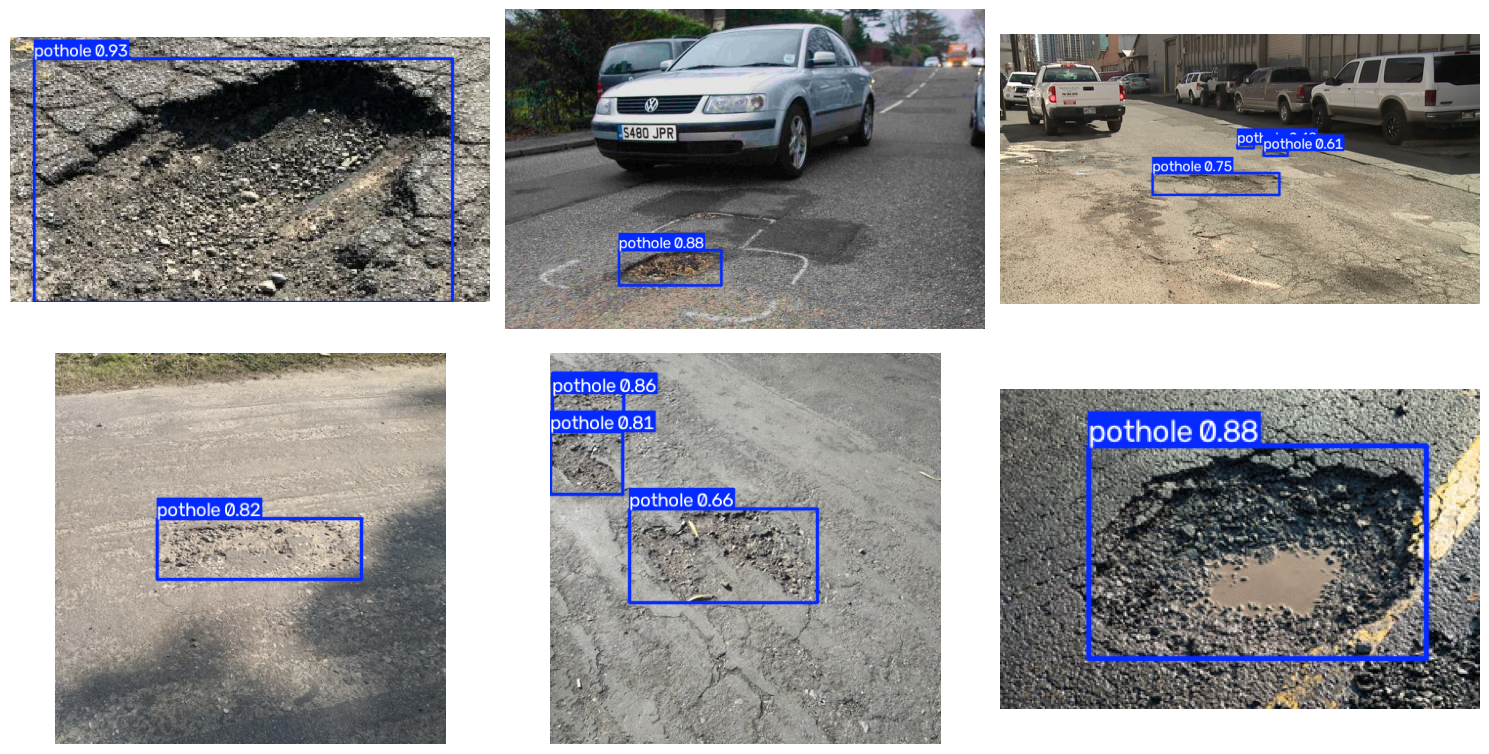

In [27]:
sample_val_images = random.sample(
    valid_image_files,
    min(6, len(valid_image_files))
)

preds = best_model.predict(
    source=sample_val_images,
    conf=0.25,
    save=False
)

plt.figure(figsize=(15, 8))

for i, r in enumerate(preds):
    plt.subplot(2, 3, i + 1)
    plt.imshow(r.plot()[:, :, ::-1])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Inference on `sample_video.mp4`

Runs detection frame-by-frame and saves an annotated output video.

In [30]:
video_path = dataset_path / "sample_video.mp4"

if video_path.exists():

    best_model.predict(
        source=str(video_path),
        conf=0.25,
        save=True,
        project="/content/runs/detect/pothole_runs",
        name="video_inference",
        exist_ok=True,
    )

    print("Annotated video saved under:")
    print("/content/runs/detect/pothole_runs/video_inference/")

else:
    print("sample_video.mp4 not found at", video_path)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/375) /kaggle/input/potholes-detection-yolov8/sample_video.mp4: 384x640 11 potholes, 20.3ms
video 1/1 (frame 2/375) /kaggle/input/potholes-detection-yolov8/sample_video.mp4: 384x640 14 potholes, 10.7ms
video 1/1 (frame 3/375) /kaggle/input/potholes-detection-yolov8/sample_video.mp4: 384x640 13 potholes, 10.6ms
video 1/1 (frame 4/375) /kaggle/input/potholes-detection-yolov8/sample_video.mp4: 384x640 14 potholes, 10.7ms
video 1/1 (frame 5/

## 11. Export the Trained Model

Export to ONNX (or other formats) for deployment outside of Python/Ultralytics if needed.

In [29]:
best_model.export(format="onnx")  # creates best.onnx next to best.pt


Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/pothole_runs/yolov8s_pothole/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 302ms
Prepared 4 packages in 1.03s
Installed 4 packages in 265ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.29.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 2.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 

'/content/runs/detect/pothole_runs/yolov8s_pothole/weights/best.onnx'

## Next Steps / Things to Tune

- If mAP is low: try more epochs, a larger model (`yolov8m.pt`), or more aggressive augmentation.
- If overfitting (train metrics much better than val): add more augmentation, reduce model size, or get more data.
- If potholes are small/far away in frames: consider training at a higher `imgsz` (e.g. 960 or 1280).
- Check `pothole_runs/yolov8s_pothole/` for all logs, weights, and plots saved automatically by Ultralytics.
